In [1]:
import os, math, json, random, numpy as np
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from PIL import Image, ImageDraw
import cv2

from sklearn.preprocessing import StandardScaler
import umap

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cpu


In [11]:
# ---------- ADAPTA AQUÍ ----------
# Directorios donde están las imágenes y máscaras GT (indexadas por clase)
# DIR_IMAGES = Path("data/images")   # p.ej. .../images
# DIR_LABELS = Path("data/labels")   # p.ej. .../labels



DIR_MODA = Path("modanet")

DIR_IMAGENES = DIR_MODA / "images"
DIR_LABELS = DIR_MODA / "annotations-seg"
DIR_PRED_DINO = DIR_MODA / "pred_dino"
DIR_PRED_SEGFORMER = DIR_MODA / "pred_segformer"


IM_DIR = DIR_IMAGENES
JSON_DIR = DIR_LABELS  # carpeta con *.json (uno por imagen)
#JSON_DIR = Path("data/annotations")# carpeta con *.json (uno por imagen)

IMG_EXT = ".jpg" 
MASK_EXT = ".png"

# Nombres de clase finales (después del mapeo). Ajusta orden y cantidad.
id2label_original = {1:"bag", 2:"belt", 3:"boots", 4:"footwear", 5:"outer",
                   6:"dress", 7:"sunglasses", 8:"pants", 9:"top", 10:"shorts",
                   11:"skirt", 12:"headwear", 13:"scarf & tie"}

class_names = ['Background', 
           'Hat',
           'Hair', 
           'Sunglasses', 
           'Upper-clothes', 
           'Skirt', 
           'Pants', 
           'Dress', 
           'Belt', 
           'Left-shoe', 
           'Right-shoe', 
           'Face', 
           'Left-leg', 
           'Right-leg', 
           'Left-arm', 
           'Right-arm', 
           'Bag', 
           'Scarf']

NUM_CLASSES = len(class_names)

# Mapeo: id_original → id_final (ejemplo). 
# Si tu dataset ya viene con ids finales, deja mapping = {i:i}.
# ---------- ADAPTA AQUÍ ----------
label_mapping = {
    # original_id : final_id
    0: 0,   # fondo
    1: 1,   # top
    2: 2,   # pants
    3: 3,   # shoes
    4: 4,   # coat
}
label_mapping = {
    # original_id : final_id
    0:0,                # Background
    0:2,                # Hair -> (ignorar)
    0:11,               # Face -> (ignorar)
    0:12,               # Left/Right-arm -> (ignorar)
    0:13,               # Left/Right-leg -> (ignorar)
    0:14,               # Left/Right-arm -> (ignorar)
    0:15,               # Left/Right-arm -> (ignorar)
    1:16,               # Bag
    2:8,
    
    3:0,
                                    # Belt
    4:9,
    4:10,               # Left/Right-shoe -> footwear
    
    5:0,

    6:7,                # Dress
    7:3,                # Sunglasses
    8:6,                # Pants
    9:4,                # Upper-clothes -> top
    
    10:0,
                                  # Shorts -> pants
    11:5,               # Skirt
    12:1,               # Hat -> headwea
    13:17               # Scarf -> scarf & tie
}


json_files = sorted(list(JSON_DIR.glob("*.json")))
assert len(json_files) > 0, f"No se encontraron JSON en: {JSON_DIR}"

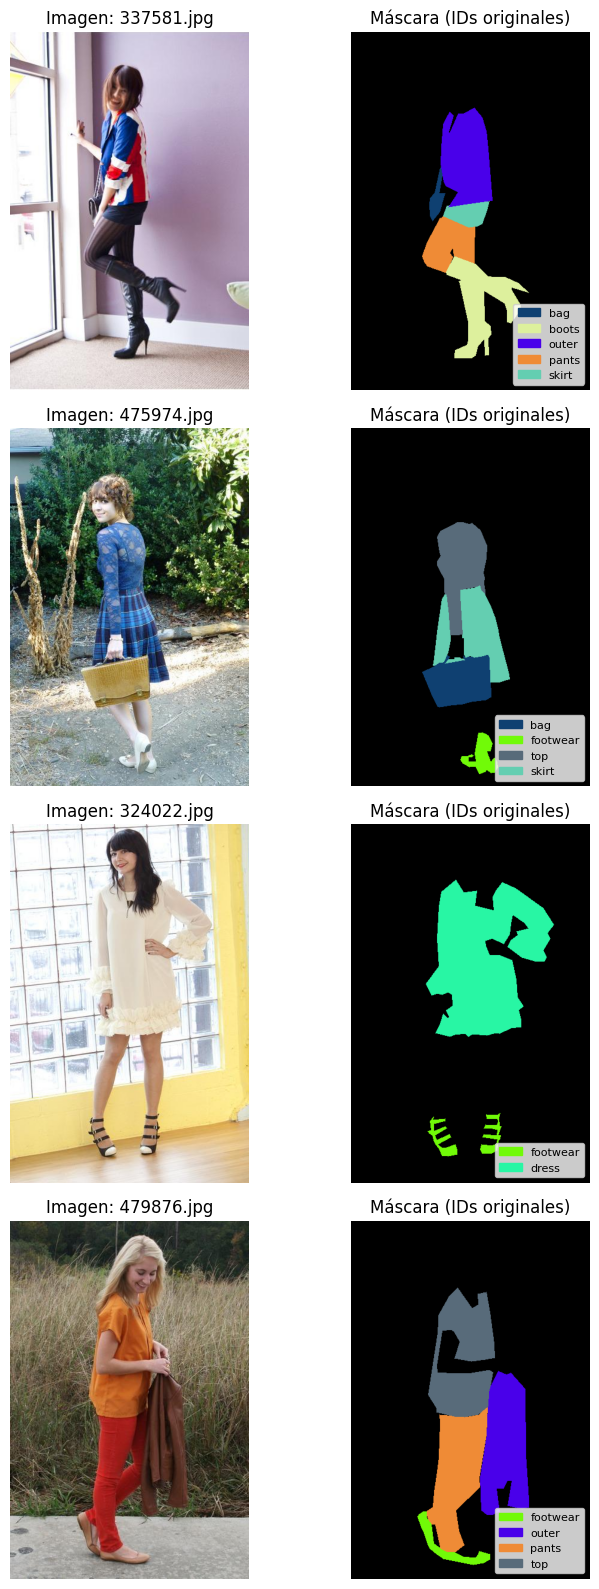

In [12]:
# ------------------------------------------------------------
# 1) UTILIDADES DE ETIQUETAS Y CARGA (funciones del profesor)
#    - Construimos MÁSCARA desde polígonos del JSON
# ------------------------------------------------------------
def load_annotations(json_path):
    """
    Lee un JSON con lista de objetos:
      [{"category_id":"5", "bounding-box": {...}}, ...], "segmentation":[[x1,y1,x2,y2,...]], "iscrowd":0
    Retorna la lista tal cual (normalizando category_id a int).
    """
    with open(json_path, 'r') as f:
        anns = json.load(f)
    for a in anns:
        if isinstance(a.get('category_id', None), str):
            try:
                a['category_id'] = int(a['category_id'])
            except Exception:
                pass
    return anns

def polygons_to_mask(img_size_hw, anns, background_id=0):
    """
    Rasteriza polígonos a una máscara HxW de IDs de clase (IDs ORIGINALES).
    - img_size_hw: (H, W)
    - anns: lista de anotaciones. Cada anotación puede tener múltiples polígonos en 'segmentation'
    Devuelve: mask (np.int64) de tamaño HxW con IDs de clase.
    """
    H, W = img_size_hw
    mask = Image.new('I', (W, H), color=background_id)  # 'I' = 32-bit entero
    draw = ImageDraw.Draw(mask)

    for ann in anns:
        cat = int(ann.get('category_id', background_id))
        seg = ann.get('segmentation', [])
        for poly in seg:
            if not poly:
                continue
            pts = list(zip(poly[0::2], poly[1::2]))  # (x,y)
            draw.polygon(pts, fill=cat)
    return np.array(mask, dtype=np.int64)

def color_palette(n, seed=10):
    rng = np.random.RandomState(seed)
    return [tuple(int(x) for x in rng.randint(0,255,3)) for _ in range(n)]

PALETTE = color_palette(64)

def overlay_mask(img_rgb, mask_ids, alpha=0.5, ignore_ids=(0,)):
    """
    Superpone la máscara (IDs) sobre la imagen RGB.
    ignore_ids: IDs que no se colorean (e.g., 0 = fondo)
    """
    color = np.zeros_like(img_rgb)
    uniq = np.unique(mask_ids)
    for cid in uniq:
        if cid in ignore_ids:
            continue
        color[mask_ids == cid] = PALETTE[int(cid) % len(PALETTE)]
    return cv2.addWeighted(img_rgb, 1-alpha, color, alpha, 0)

def create_legend(pred_seg, id2label):
    present = [int(c) for c in np.unique(pred_seg) if c != 0]  # sin fondo
    patches = []
    for cid in present:
        r,g,b = PALETTE[cid % len(PALETTE)]
        patches.append(mpatches.Patch(color=(r/255, g/255, b/255), label=id2label.get(cid, str(cid))))
    return patches

def apply_label_map(mask_np: np.ndarray, mapping: dict, ignore_value: int = -1):
    """
    Aplica un mapeo de ids: ORIGINAL -> FINAL.
    Los ids no mapeados quedan en ignore_value (p.ej. -1).
    """
    out = np.full_like(mask_np, fill_value=ignore_value)
    for k, v in mapping.items():
        out[mask_np == k] = v
    return out

def load_image_for_json(jp: Path):
    """
    Dado un JSON path, busca su imagen emparejada por stem.
    """
    stem = jp.stem
    for ext in ('.jpg', '.jpeg', '.png'):
        p = IM_DIR / f"{stem}{ext}"
        if p.exists():
            return Image.open(p).convert('RGB'), p
    raise FileNotFoundError(f"No encontré imagen para {jp.name} en {IM_DIR}")

# (Opcional) visualizador rápido de muestras
def show_samples(n=4, alpha=0.5):
    picks = random.sample(json_files, k=min(n, len(json_files)))
    fig, axes = plt.subplots(len(picks), 2, figsize=(8, 4*len(picks)))
    if len(picks) == 1:
        axes = np.array([axes])

    for row, jp in enumerate(picks):
        anns = load_annotations(jp)
        img, img_path = load_image_for_json(jp)
        img_np = np.array(img)
        H, W = img_np.shape[:2]
        mask_orig = polygons_to_mask((H, W), anns, background_id=0)  # IDs ORIGINALES (del JSON)

        vis = overlay_mask(img_np, mask_orig, alpha=alpha)
        patches = create_legend(mask_orig, id2label_original)

        axes[row, 0].imshow(img_np); axes[row, 0].set_title(f"Imagen: {img_path.name}"); axes[row, 0].axis('off')
        axes[row, 1].imshow(vis);     axes[row, 1].set_title("Máscara (IDs originales)"); axes[row, 1].axis('off')
        if patches: axes[row, 1].legend(handles=patches, loc='lower right', frameon=True, fontsize=8)

    plt.tight_layout(); plt.show()

show_samples(4,1)  # <- quita el comentario si quieres ver ejemplos

In [13]:
# ------------------------------------------------------------
# 2) DICE POR CLASE
#    "Es importante que el Dice solo se calcule en los labels del GT de cada imagen".
#    → cuando la clase NO aparece en el GT, ponemos NaN (y luego promediamos ignorando NaN).
# ------------------------------------------------------------
def dice_per_class_image(gt_final: np.ndarray, pred_final: np.ndarray, num_classes: int):
    scores = np.full((num_classes,), np.nan, dtype=np.float32)
    for c in range(num_classes):
        gt_c = (gt_final == c)
        if gt_c.sum() == 0:
            continue  # clase ausente en GT → NaN
        pred_c = (pred_final == c)
        inter  = np.logical_and(gt_c, pred_c).sum()
        total  = gt_c.sum() + pred_c.sum()
        scores[c] = (2.0 * inter / total) if total > 0 else 0.0
    return scores

def aggregate_dice_over_dataset(results_list, num_classes: int):
    A = np.vstack(results_list)  # [N_imgs, num_classes]
    return np.nanmean(A, axis=0)

def plot_bars(values, labels, title="Dice por clase (promedio dataset)", ylabel="Dice"):
    x = np.arange(len(values))
    plt.figure(figsize=(9,5))
    plt.bar(x, values)
    plt.xticks(x, labels, rotation=45, ha='right')
    plt.ylabel(ylabel)
    plt.ylim(0, 1.0)
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [15]:
# ------------------------------------------------------------
# 3) PREDICCIÓN DE SEGMENTACIÓN (para el Dice)
#    Usa SegformerForSemanticSegmentation (o tu propio modelo checkpoint).
#    Luego MAPEAMOS las predicciones a tus IDs FINALES con 'label_mapping'.
# ------------------------------------------------------------
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

# ---------- ADAPTA AQUÍ ----------
SEG_CKPT_PRED = "mattmdjaga/segformer_b2_clothes"  # usa tu checkpoint real si lo tienes


seg_iproc_pred = SegformerImageProcessor.from_pretrained(SEG_CKPT_PRED)
seg_model_pred = SegformerForSemanticSegmentation.from_pretrained(SEG_CKPT_PRED).to(device)
seg_model_pred.eval()

def segformer_predict_mask_final(image_pil, mapping):
    """
    Corre el segmentador, obtiene logits → argmax → ids ORIGINALES del checkpoint,
    y los mapea a tus IDs FINALES usando 'mapping' (id_original->id_final).
    """
    H, W = image_pil.size[1], image_pil.size[0]
    inputs = seg_iproc_pred(images=image_pil, return_tensors="pt").to(device)
    with torch.no_grad():
        out = seg_model_pred(**inputs)   # logits [1, C, h', w']
    logits_up = F.interpolate(out.logits, size=(H, W), mode="bilinear", align_corners=False)
    pred_ids  = logits_up.argmax(dim=1).squeeze(0).detach().cpu().numpy().astype(np.int32)  # IDs ORIGINALES (del ckpt)
    pred_final = apply_label_map(pred_ids, mapping, ignore_value=-1)
    pred_final[pred_final < 0] = 0  # lo no mapeado -> fondo (ajusta si quieres ignorar)
    return pred_final

/home/mbustamc/Documentos/diplomados/dia_2025/cc66t_reconocimiento-visual/cc66t_laboratorios/.venv/lib/python3.11/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


In [ ]:
# ------------------------------------------------------------
# 4) ENCODERS: DINO (dinov2) y SegFormerModel para FEATURES enmascarados por región
# ------------------------------------------------------------
import torchvision.transforms as T
from transformers import SegformerModel

def load_dino_model(device=device):
    pre = T.Compose([
        T.Resize((518, 518)),  # múltiplo de 14
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    # Opción 1: dinov2 hub
    try:
        model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
        model.eval().to(device)
        return model, 14, 384, pre
    except Exception as e:
        print("torch.hub dinov2 falló, intento timm:", e)
    # Opción 2: timm ViT DINO
    try:
        import timm
        model = timm.create_model('vit_small_patch16_224.dino', pretrained=True)
        model.eval().to(device)
        pre = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ])
        return model, 16, model.embed_dim, pre
    except Exception as e:
        raise RuntimeError("No pude cargar DINO. Ajusta loader/pesos.") from e

def get_vit_token_grid(model, img_tensor):
    """
    Devuelve tokens [1,P,C] y (ph,pw), admitiendo timm.forward_features o dinov2.get_intermediate_layers.
    """
    model.eval()
    with torch.no_grad():
        if hasattr(model, 'forward_features'):
            feats = model.forward_features(img_tensor)  # ViT: [B,N,C] (posible CLS)
            if feats.dim() == 3:
                B, N, C = feats.shape
                phpw = int(math.sqrt(max(N-1, 1)))
                if (phpw*phpw + 1) == N:
                    tokens = feats[:,1:,:]; ph = pw = phpw
                else:
                    ph = pw = int(math.sqrt(N)); tokens = feats
                return tokens, (ph, pw)
            elif feats.dim() == 4:
                B, C, H_, W_ = feats.shape
                tokens = feats.permute(0,2,3,1).reshape(B, H_*W_, C)
                return tokens, (H_, W_)
            else:
                raise RuntimeError("Formato forward_features no reconocido.")
        elif hasattr(model, 'get_intermediate_layers'):
            out = model.get_intermediate_layers(img_tensor, n=1)[0]  # [B,N,C]
            B, N, C = out.shape
            ph = pw = int(math.sqrt(N-1))
            tokens = out[:,1:,:]  # sin CLS
            return tokens, (ph, pw)
        else:
            raise RuntimeError("El modelo ViT no expone tokens.")

def load_segformer_encoder(model_name=SEG_CKPT_PRED, device=device):
    iproc = SegformerImageProcessor.from_pretrained(model_name)
    enc   = SegformerModel.from_pretrained(model_name).to(device)
    enc.eval()
    return iproc, enc

def segformer_token_grid(image_pil, image_processor, model, device=device):
    """
    Devuelve tokens [1,P,C] y (ph,pw) del last_hidden_state del encoder.
    """
    inputs = image_processor(images=image_pil, return_tensors="pt")
    px = inputs["pixel_values"].to(device)  # [1,3,H',W']
    with torch.no_grad():
        out = model(pixel_values=px)       # last_hidden_state [1,C,ph,pw]
    feats = out.last_hidden_state
    B, C, ph, pw = feats.shape
    tokens = feats.permute(0,2,3,1).reshape(B, ph*pw, C)  # [1,P,C]
    return tokens, (ph, pw)

def region_embeddings_from_token_grid(token_grid: torch.Tensor,
                                      grid_hw: tuple,
                                      gt_final: np.ndarray,
                                      num_classes: int):
    """
    Promedia tokens por clase usando la máscara GT (FINAL) reescalada a la rejilla.
    """
    assert token_grid.shape[0] == 1
    ph, pw = grid_hw
    C = token_grid.shape[-1]

    mask_t = torch.from_numpy(gt_final[None, None, ...]).float()  # [1,1,H,W]
    mask_small = F.interpolate(mask_t, size=(ph, pw), mode='nearest').long().squeeze()  # [ph,pw]
    tokens_hw = token_grid[0].reshape(ph, pw, C)  # [ph,pw,C]

    embs, labels = [], []
    for c in range(num_classes):
        sel = (mask_small == c)
        if sel.any():
            vec = tokens_hw[sel].mean(dim=0)  # [C]
            embs.append(vec.detach().cpu().numpy())
            labels.append(c)
    if len(embs) == 0:
        return np.zeros((0, C), dtype=np.float32), []
    return np.vstack(embs), labels

def umap_scatter(embs: np.ndarray, labels: list, class_names: list, title: str):
    if embs.shape[0] < 2:
        print(f"No hay suficientes puntos para UMAP en {title}.")
        return
    X = StandardScaler().fit_transform(embs)
    reducer = umap.UMAP(n_components=2, metric="cosine", random_state=42)
    Y = reducer.fit_transform(X)

    plt.figure(figsize=(7,6))
    for c in sorted(set(labels)):
        idx = [i for i, cc in enumerate(labels) if cc == c]
        plt.scatter(Y[idx,0], Y[idx,1], s=12, alpha=0.85, label=class_names[c])
    plt.title(title)
    plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()



In [ ]:
# ------------------------------------------------------------
# 5) EJECUCIÓN: 
#    - Para cada JSON: crear GT desde polígonos → mapear a IDs finales
#    - Predecir máscara (mapeada) para Dice
#    - Extraer embeddings por clase (GT enmascarado) con DINO y SegFormer (encoders)
#    - Promediar Dice; UMAP para cada encoder por separado
# ------------------------------------------------------------
from sklearn.metrics import ConfusionMatrixDisplay  # (si luego quieres añadir análisis extra)

# Cargar encoders
dino_model, dino_patch, dino_dim, dino_pre = load_dino_model(device)
seg_iproc_enc, seg_encoder = load_segformer_encoder(model_name=SEG_CKPT_PRED, device=device)

dice_results = []
dino_vectors, dino_labels = [], []
seg_vectors,  seg_labels  = [], []

for jp in tqdm(json_files, desc="Procesando dataset"):
    # Imagen emparejada y anotaciones
    image_pil, img_path = load_image_for_json(jp)
    anns = load_annotations(jp)

    # Construye máscara de IDs ORIGINALES y mapea a IDs FINALES
    H, W = image_pil.size[1], image_pil.size[0]
    mask_orig  = polygons_to_mask((H, W), anns, background_id=0)          # ORIGINAL
    gt_final   = apply_label_map(mask_orig, label_mapping, ignore_value=-1)# FINAL
    gt_final[gt_final < 0] = 0  # lo no mapeado -> fondo (ajusta si quieres estrategia distinta)

    # Predicción del segmentador y mapeo a IDs FINALES para DICE
    pred_final = segformer_predict_mask_final(image_pil, label_mapping)

    # DICE por clase (solo clases presentes en GT: NaN si ausentes)
    dice_img = dice_per_class_image(gt_final, pred_final, NUM_CLASSES)
    dice_results.append(dice_img)

    # Embeddings DINO (encoder) enmascarados con GT FINAL
    try:
        img_t = dino_pre(image_pil).unsqueeze(0).to(device)
        dino_tok, dino_hw = get_vit_token_grid(dino_model, img_t)
        d_embs, d_cls = region_embeddings_from_token_grid(dino_tok, dino_hw, gt_final, NUM_CLASSES)
        if len(d_cls) > 0:
            dino_vectors.append(d_embs)
            dino_labels.extend(d_cls)
    except Exception as e:
        print(f"DINO fallo en {img_path.name}: {e}")

    # Embeddings SegFormer (encoder) enmascarados con GT FINAL
    try:
        seg_tok, seg_hw = segformer_token_grid(image_pil, seg_iproc_enc, seg_encoder, device)
        s_embs, s_cls = region_embeddings_from_token_grid(seg_tok, seg_hw, gt_final, NUM_CLASSES)
        if len(s_cls) > 0:
            seg_vectors.append(s_embs)
            seg_labels.extend(s_cls)
    except Exception as e:
        print(f"SegFormer encoder fallo en {img_path.name}: {e}")

# ---- Promedio DICE por clase ----
dice_avg = aggregate_dice_over_dataset(dice_results, NUM_CLASSES)
print("\nDice promedio por clase:")
for name, val in zip(class_names, dice_avg):
    print(f"  {name:12s}: {val:.3f}")

plot_bars(dice_avg, class_names, title="Dice por clase (promedio dataset)")

# ---- UMAP por encoder ----
D = np.vstack(dino_vectors) if len(dino_vectors) else np.zeros((0, dino_dim))
S = np.vstack(seg_vectors)  if len(seg_vectors)  else np.zeros((0, seg_encoder.config.hidden_sizes[-1]))

print("DINO vectors:", D.shape, "| SegFormer vectors:", S.shape)

umap_scatter(D, dino_labels, class_names, title="Espacio de prendas con DINO (UMAP)")
umap_scatter(S, seg_labels,  class_names, title="Espacio de prendas con SegFormer (UMAP)")